# 03 -- Visualization & Insights

**Project:** Predictive Analytics for Enterprise Streaming Acquisitions  
**Course:** CMPS 451 -- Data Mining, Big Data & Analytics (Spring 2026)  
**Team:** 11

---

## Objectives
1. Generate 10 publication-quality visualizations
2. Explicitly address language bias and numVotes
3. Extract actionable business insights from the data

In [2]:

# ── Imports & Environment Setup ──
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import findspark

os.environ['HADOOP_HOME'] = r'A:\hadoop'
os.environ['SPARK_HOME'] = r'A:\spark'
os.environ['PATH'] = r'A:\hadoop\bin;' + os.environ.get('PATH', '')
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Style setup
plt.style.use('seaborn-v0_8-darkgrid')
matplotlib.rcParams.update({
    'font.size': 12,
    'figure.figsize': (12, 7),
    'figure.dpi': 150,
    'savefig.dpi': 150
})
OUTPUT_DIR = os.path.join("outputs")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

spark = (
    SparkSession.builder
    .appName("IMDb_Visualization")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# Load the Spark DataFrame — keep data distributed, do NOT call toPandas() here.
# Each plot cell below will either (a) compute a Spark aggregation and collect
# only the tiny result, or (b) sample a small fraction before collecting.
df_spark = spark.read.parquet(os.path.join(OUTPUT_DIR, "parquet", "features"))
df_spark.cache()   # cache once so repeated aggregations reuse the same scan

print(f"Dataset: {df_spark.count():,} rows, {len(df_spark.columns)} columns — staying distributed")

# Load feature metadata
with open(os.path.join(OUTPUT_DIR, "feature_columns.json")) as f:
    feat_meta = json.load(f)


Dataset: 186,201 rows, 60 columns — staying distributed


## Plot 1: Rating Distribution

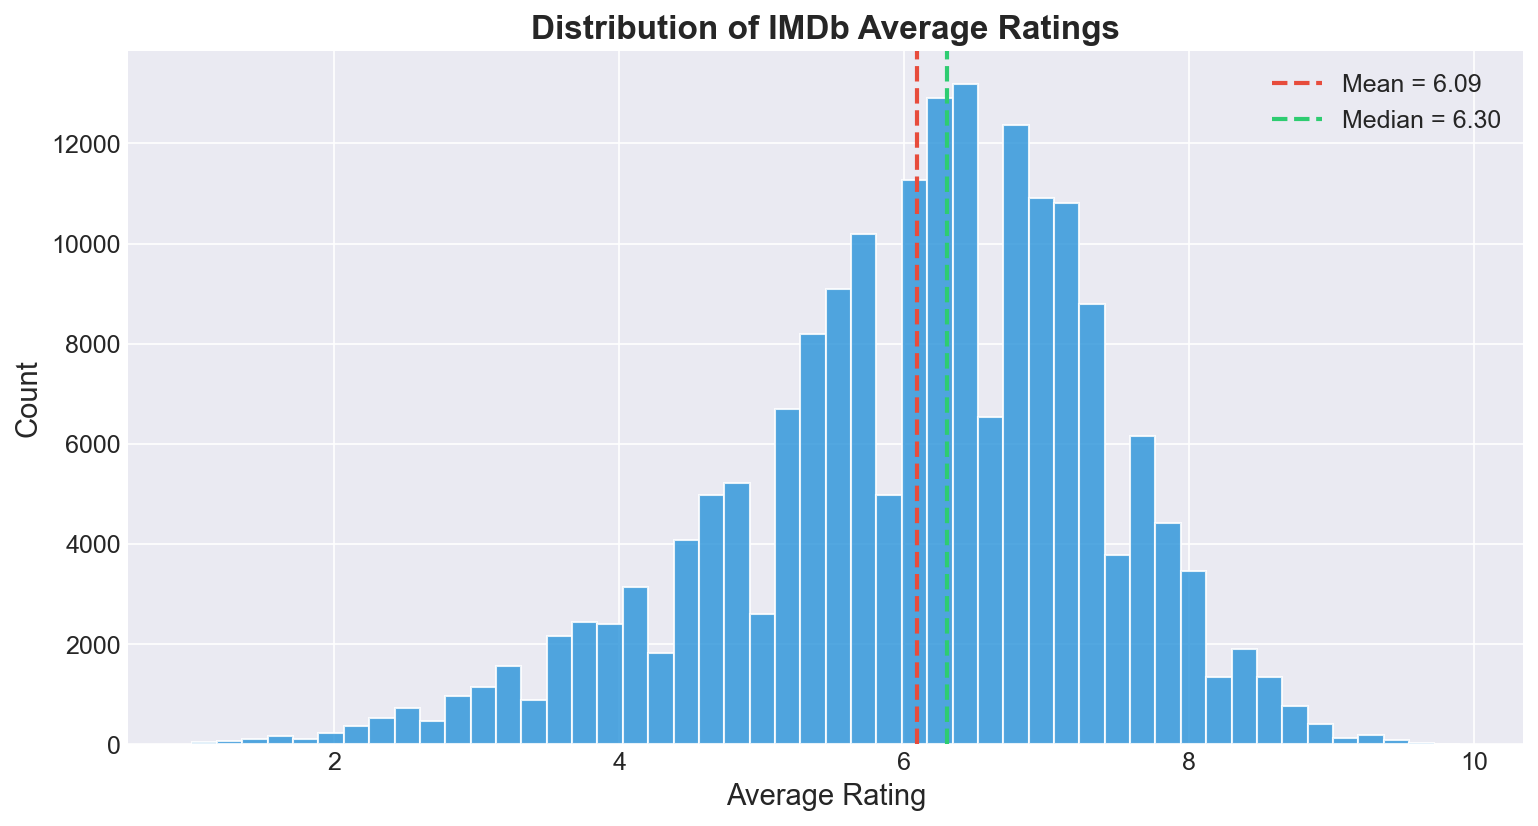

Skewness: -0.595


In [3]:

# Compute mean, median, skewness in Spark (no data moved to driver)
stats = df_spark.agg(
    F.mean("averageRating").alias("mean"),
    F.expr("percentile(averageRating, 0.5)").alias("median"),
    F.skewness("averageRating").alias("skewness")
).first()

# Collect only the single rating column for histogram (not the full wide dataset)
rating_pdf = df_spark.select("averageRating").toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(rating_pdf['averageRating'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(stats['mean'], color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Mean = {stats["mean"]:.2f}')
ax.axvline(stats['median'], color='#2ecc71', linestyle='--', linewidth=2,
           label=f'Median = {stats["median"]:.2f}')
ax.set_xlabel('Average Rating', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_title('Distribution of IMDb Average Ratings', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
plt.savefig(os.path.join(PLOTS_DIR, '01_rating_distribution.png'), bbox_inches='tight')
plt.show()
print(f"Skewness: {stats['skewness']:.3f}")


## Plot 2: Genre Popularity vs. Quality

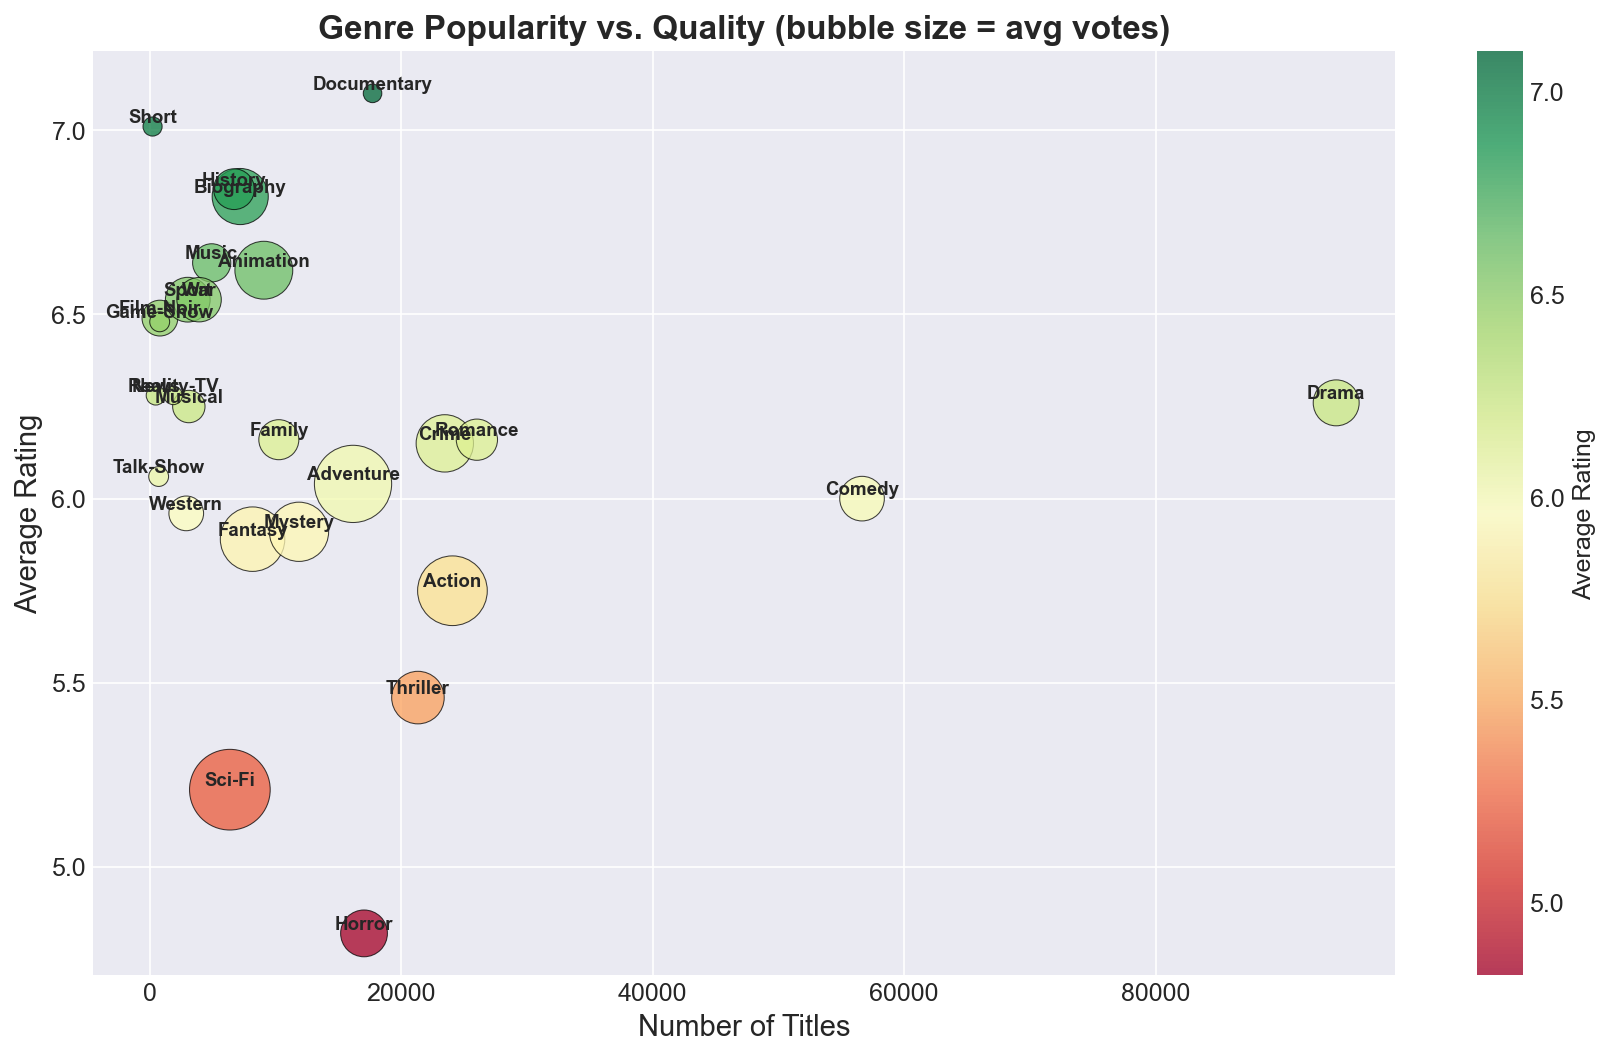

In [4]:

genre_cols = feat_meta['genre_cols']

# Single-pass Spark aggregation: count, sum-ratings, sum-votes per genre column
# Uses conditional sums so only one full scan is needed regardless of genre count
agg_exprs = []
for gc in genre_cols:
    agg_exprs += [
        F.sum(F.col(gc)).alias(f"n_{gc}"),
        F.sum(F.when(F.col(gc) == 1, F.col("averageRating"))).alias(f"r_{gc}"),
        F.sum(F.when(F.col(gc) == 1, F.col("numVotes"))).alias(f"v_{gc}"),
    ]
row = df_spark.agg(*agg_exprs).first()

genre_stats = []
for gc in genre_cols:
    n = row[f"n_{gc}"] or 0
    if n > 0:
        genre_stats.append({
            'genre': gc.replace('genre_', '').replace('_', '-'),
            'count': int(n),
            'avg_rating': round((row[f"r_{gc}"] or 0) / n, 2),
            'avg_votes':  round((row[f"v_{gc}"] or 0) / n, 0),
        })
gdf = pd.DataFrame(genre_stats)

fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    gdf['count'], gdf['avg_rating'],
    s=gdf['avg_votes'] / gdf['avg_votes'].max() * 1500,
    c=gdf['avg_rating'], cmap='RdYlGn', alpha=0.75, edgecolors='black', linewidth=0.5
)
for _, r in gdf.iterrows():
    ax.annotate(r['genre'], (r['count'], r['avg_rating']),
                fontsize=9, ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=14)
ax.set_ylabel('Average Rating', fontsize=14)
ax.set_title('Genre Popularity vs. Quality (bubble size = avg votes)', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Average Rating')
plt.savefig(os.path.join(PLOTS_DIR, '02_genre_bubble.png'), bbox_inches='tight')
plt.show()


## Plot 3: Runtime vs. Rating

C:\Users\Ezz\AppData\Local\Temp\ipykernel_19328\3278278535.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf_rt, x='runtimeBin', y='averageRating', palette='viridis', ax=ax)


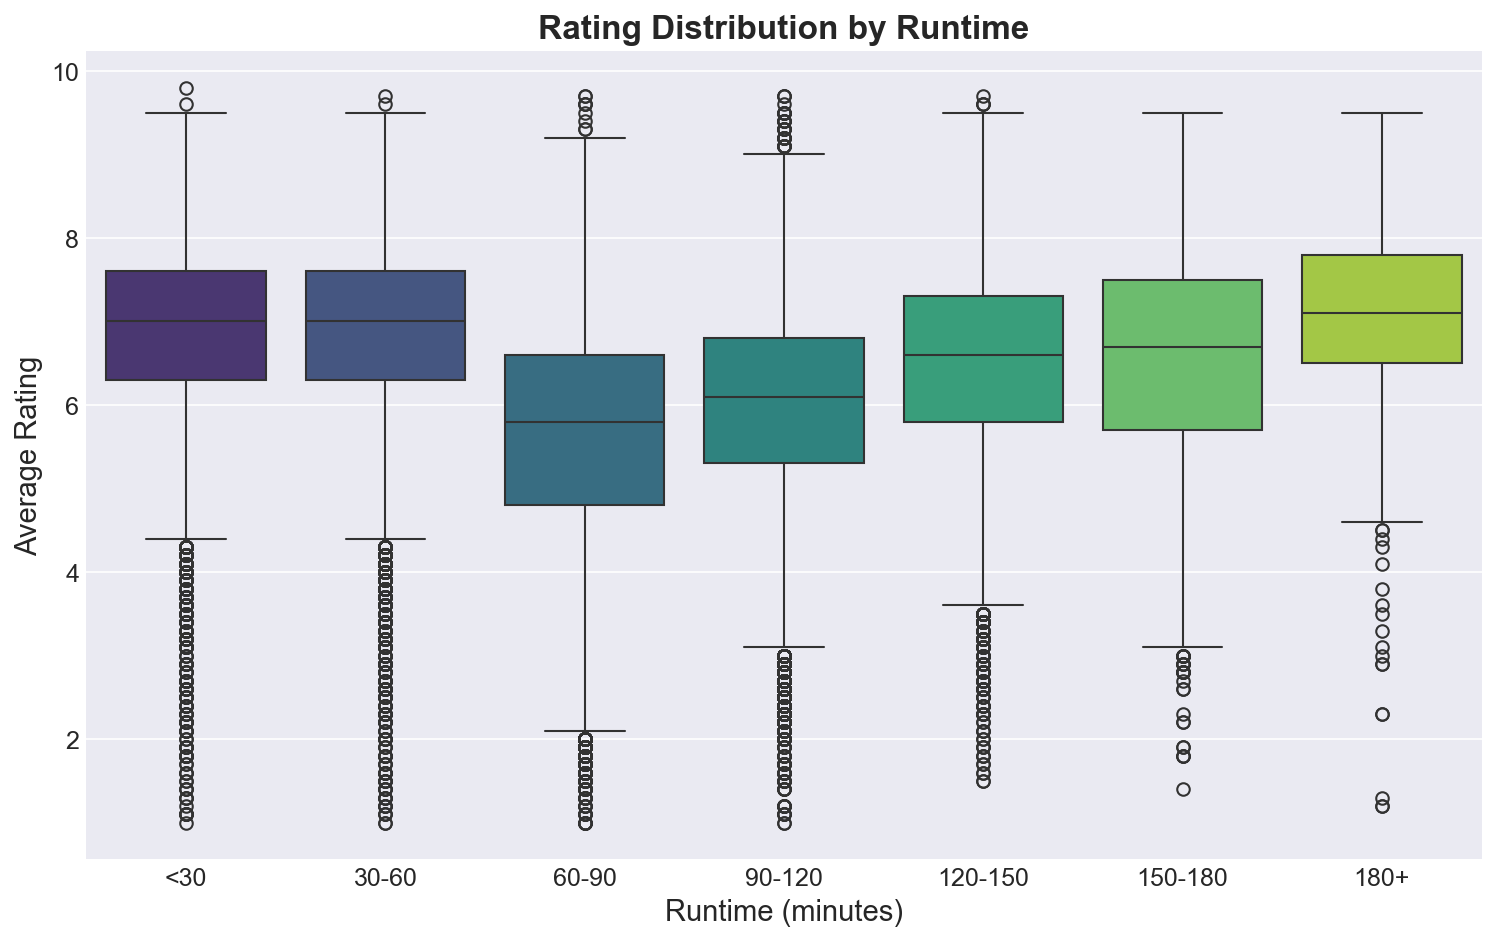

In [5]:

# Sample in Spark (only the 2 needed columns) before collecting
pdf_rt = (
    df_spark
    .filter((F.col("runtimeMinutes") > 10) & (F.col("runtimeMinutes") < 300))
    .select("runtimeMinutes", "averageRating")
    .sample(fraction=0.5, seed=42)
    .toPandas()
)
pdf_rt['runtimeBin'] = pd.cut(pdf_rt['runtimeMinutes'],
    bins=[0, 30, 60, 90, 120, 150, 180, 300],
    labels=['<30', '30-60', '60-90', '90-120', '120-150', '150-180', '180+'])

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=pdf_rt, x='runtimeBin', y='averageRating', palette='viridis', ax=ax)
ax.set_xlabel('Runtime (minutes)', fontsize=14)
ax.set_ylabel('Average Rating', fontsize=14)
ax.set_title('Rating Distribution by Runtime', fontsize=16, fontweight='bold')
plt.savefig(os.path.join(PLOTS_DIR, '03_runtime_vs_rating.png'), bbox_inches='tight')
plt.show()


## Plot 4: Rating Trends Over Decades

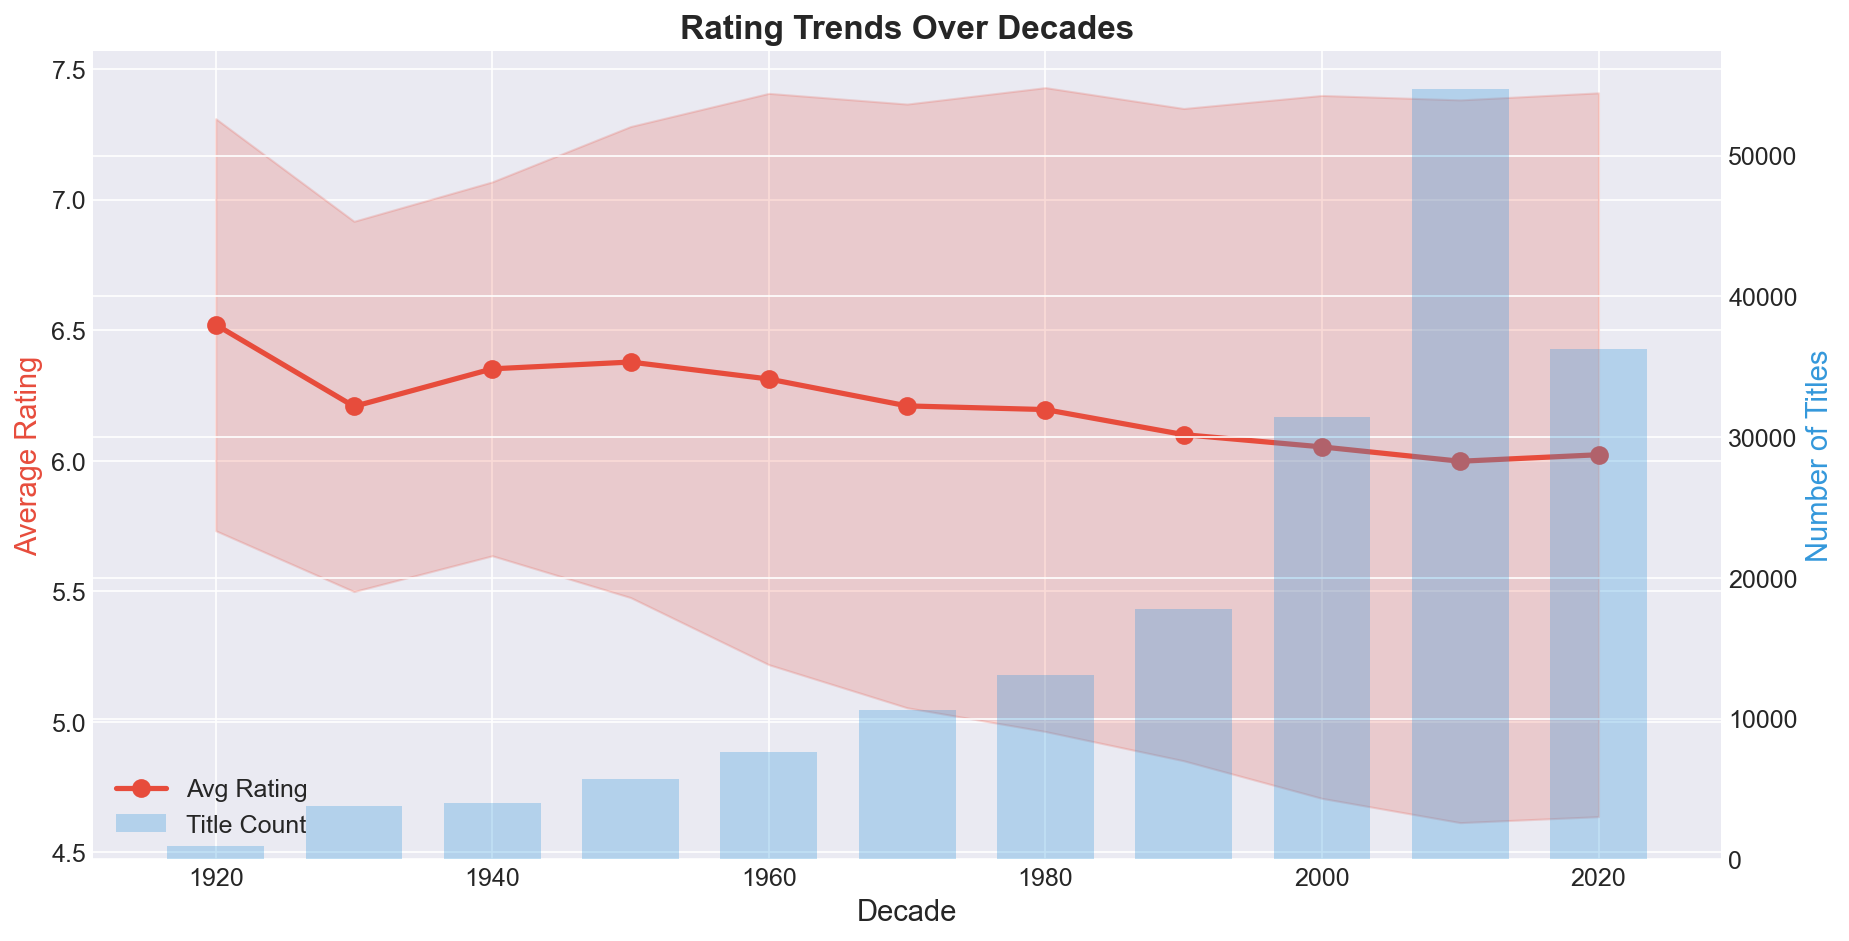

In [6]:

# Compute decade trends in Spark — collect only the small grouped result
decade_stats = (
    df_spark
    .filter((F.col("decade") >= 1920) & (F.col("decade") <= 2020))
    .groupBy("decade")
    .agg(
        F.round(F.mean("averageRating"), 3).alias("avg_rating"),
        F.count("*").alias("count"),
        F.round(F.stddev("averageRating"), 3).alias("std_rating")
    )
    .orderBy("decade")
    .toPandas()
)

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

ax1.plot(decade_stats['decade'], decade_stats['avg_rating'], 'o-',
         color='#e74c3c', linewidth=2.5, markersize=8, label='Avg Rating')
ax1.fill_between(decade_stats['decade'],
    decade_stats['avg_rating'] - decade_stats['std_rating'],
    decade_stats['avg_rating'] + decade_stats['std_rating'],
    alpha=0.2, color='#e74c3c')

ax2.bar(decade_stats['decade'], decade_stats['count'],
        width=7, alpha=0.3, color='#3498db', label='Title Count')

ax1.set_xlabel('Decade', fontsize=14)
ax1.set_ylabel('Average Rating', fontsize=14, color='#e74c3c')
ax2.set_ylabel('Number of Titles', fontsize=14, color='#3498db')
ax1.set_title('Rating Trends Over Decades', fontsize=16, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12)

plt.savefig(os.path.join(PLOTS_DIR, '04_decade_trends.png'), bbox_inches='tight')
plt.show()


## Plot 5: Language Bias Analysis

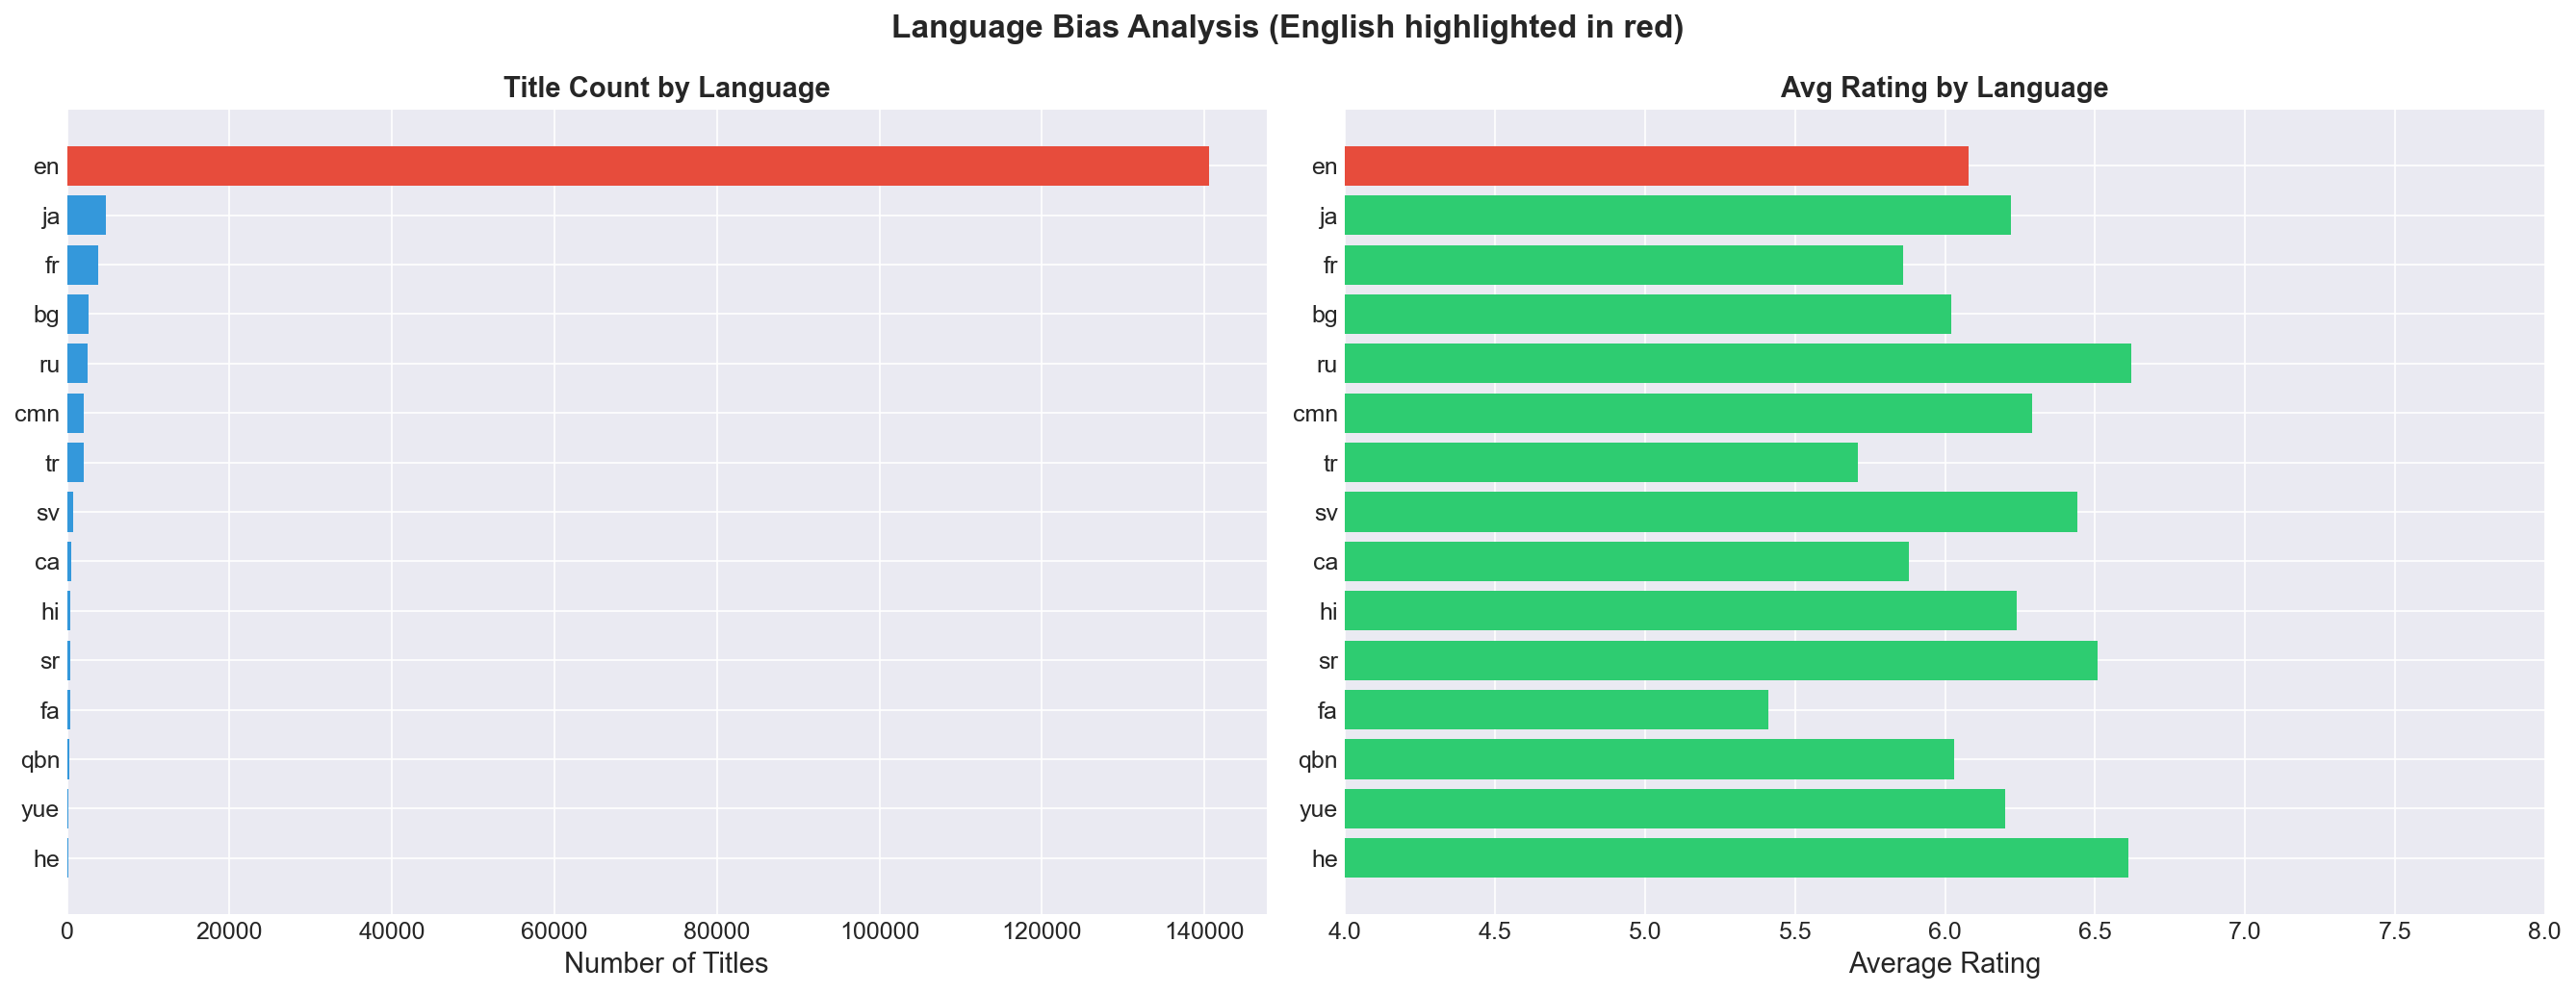


INSIGHT: English titles represent 75.5% of the dataset.
This creates a significant bias that must be considered in model interpretation.


In [8]:

# Compute language stats in Spark — collect only the top-15 grouped result
lang_stats = (
    df_spark
    .filter(F.col("primaryLanguage").isNotNull())
    .groupBy("primaryLanguage")
    .agg(
        F.count("*").alias("count"),
        F.round(F.mean("averageRating"), 2).alias("avg_rating")
    )
    .orderBy("count", ascending=False)
    .limit(15)
    .toPandas()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

colors = ['#e74c3c' if lang == 'en' else '#3498db' for lang in lang_stats['primaryLanguage']]
ax1.barh(lang_stats['primaryLanguage'], lang_stats['count'], color=colors)
ax1.set_xlabel('Number of Titles', fontsize=14)
ax1.set_title('Title Count by Language', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

colors2 = ['#e74c3c' if lang == 'en' else '#2ecc71' for lang in lang_stats['primaryLanguage']]
ax2.barh(lang_stats['primaryLanguage'], lang_stats['avg_rating'], color=colors2)
ax2.set_xlabel('Average Rating', fontsize=14)
ax2.set_title('Avg Rating by Language', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.set_xlim(4, 8)

fig.suptitle('Language Bias Analysis (English highlighted in red)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '05_language_bias.png'), bbox_inches='tight')
plt.show()

eng_pct_row = df_spark.agg(
    (F.sum(F.when(F.col("isEnglish") == 1, 1).otherwise(0)) * 100.0 / F.count("*")).alias("eng_pct")
).first()
print(f"\nINSIGHT: English titles represent {eng_pct_row['eng_pct']:.1f}% of the dataset.")
print("This creates a significant bias that must be considered in model interpretation.")


## Plot 6: numVotes vs. Rating 

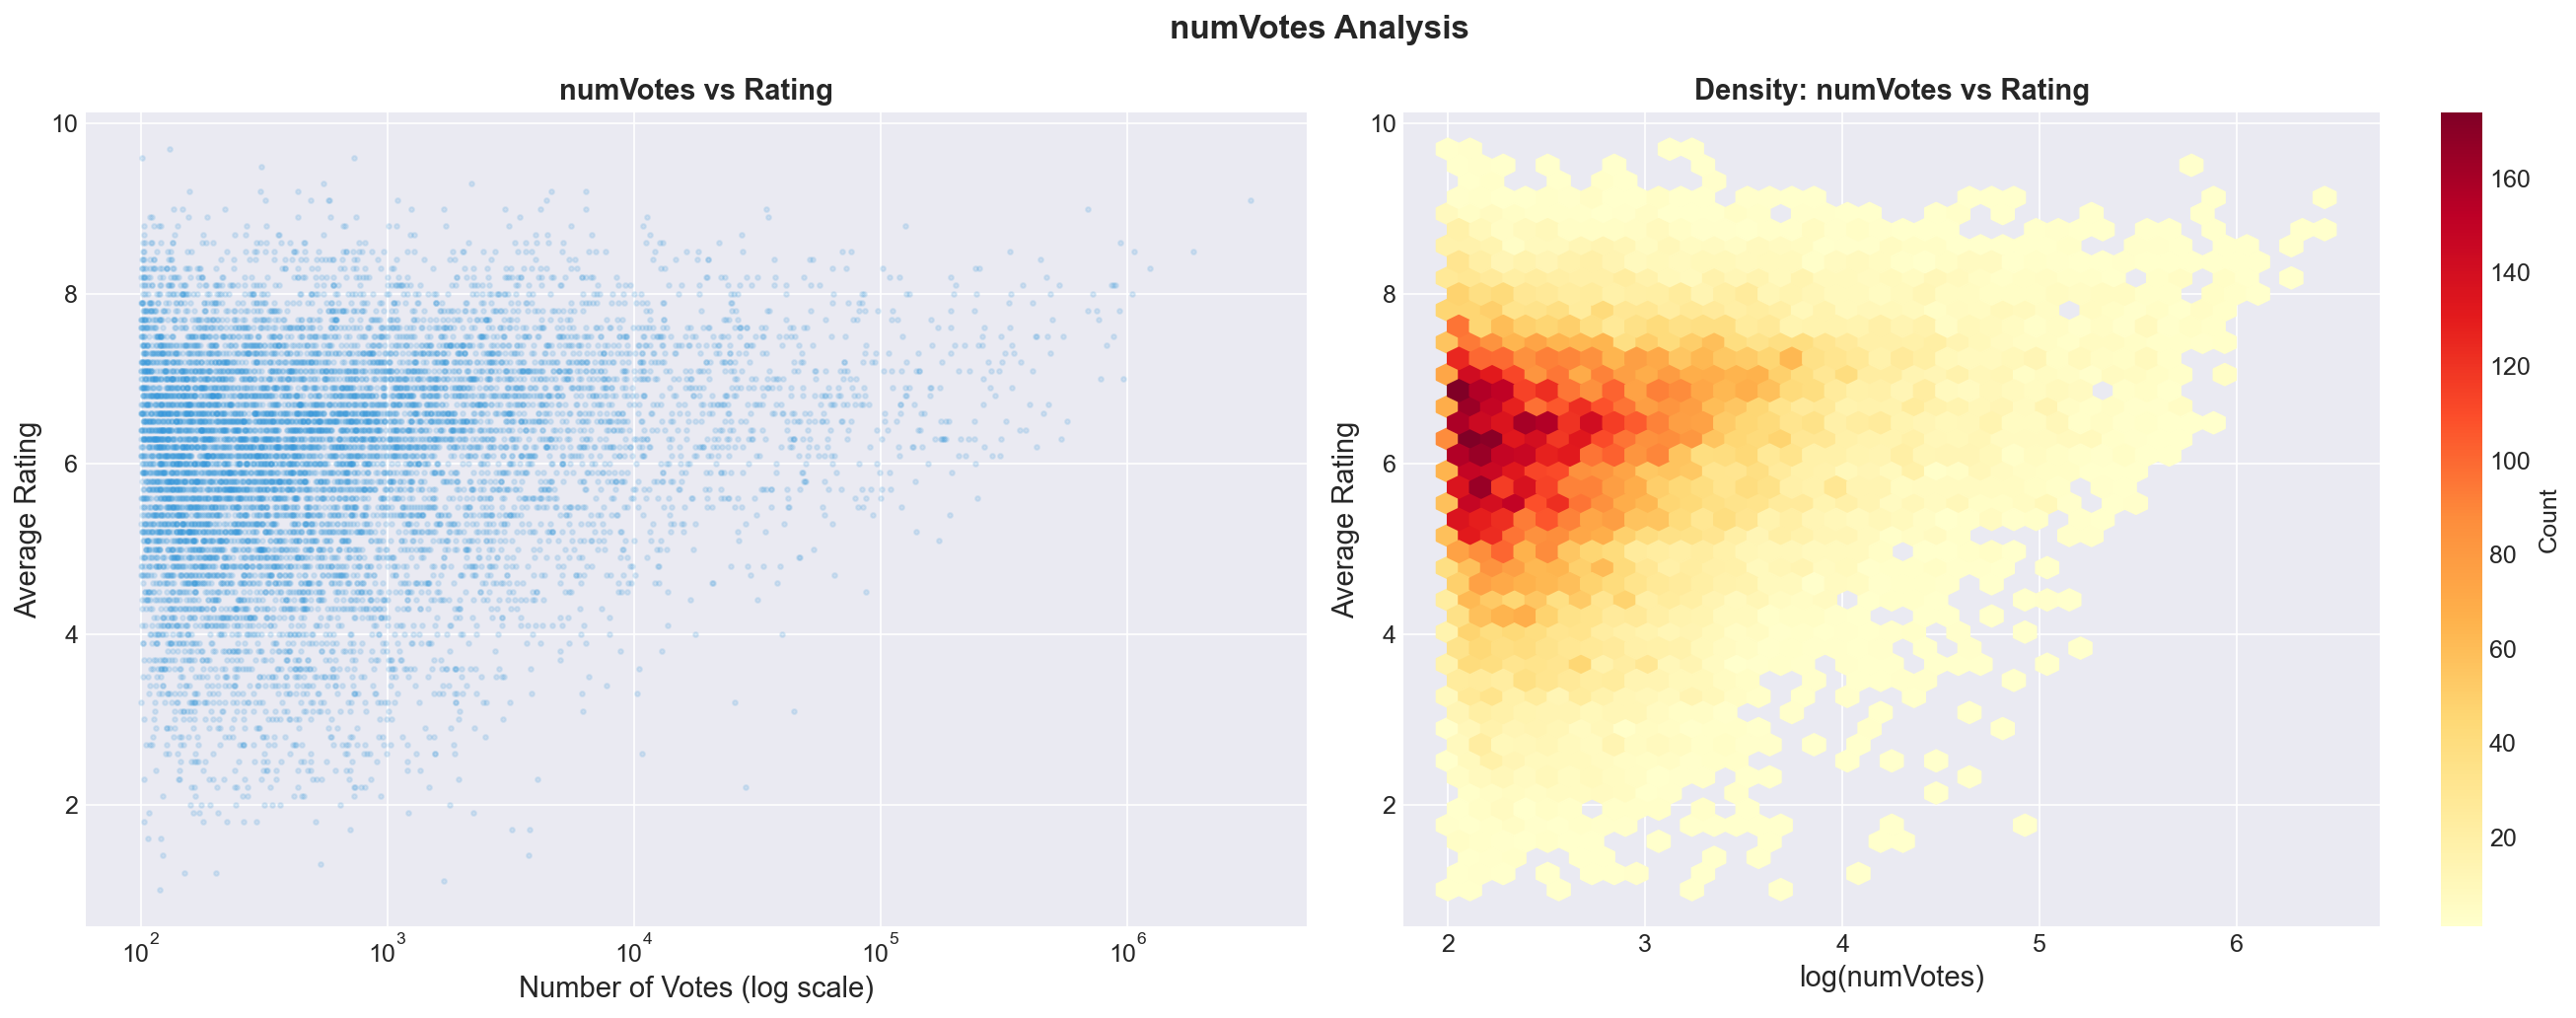

INSIGHT: Titles with more votes tend to cluster around 6-8 rating range.
Low-vote titles show higher variance 


In [9]:

# Sample only the 2 needed columns in Spark before collecting
votes_pdf = (
    df_spark
    .select("numVotes", "averageRating")
    .sample(fraction=0.15, seed=42)
    .toPandas()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: Scatter (log scale)
scatter_sample = votes_pdf.sample(min(10000, len(votes_pdf)), random_state=42)
ax1.scatter(scatter_sample['numVotes'], scatter_sample['averageRating'],
            alpha=0.15, s=5, c='#3498db')
ax1.set_xscale('log')
ax1.set_xlabel('Number of Votes (log scale)', fontsize=14)
ax1.set_ylabel('Average Rating', fontsize=14)
ax1.set_title('numVotes vs Rating', fontsize=14, fontweight='bold')

# Right: Hexbin for density
hb = ax2.hexbin(np.log10(votes_pdf['numVotes']), votes_pdf['averageRating'],
                gridsize=40, cmap='YlOrRd', mincnt=1)
ax2.set_xlabel('log(numVotes)', fontsize=14)
ax2.set_ylabel('Average Rating', fontsize=14)
ax2.set_title('Density: numVotes vs Rating', fontsize=14, fontweight='bold')
plt.colorbar(hb, ax=ax2, label='Count')

fig.suptitle('numVotes Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '06_numvotes_analysis.png'), bbox_inches='tight')
plt.show()

print("INSIGHT: Titles with more votes tend to cluster around 6-8 rating range.")
print("Low-vote titles show higher variance ")


## Plot 7: Feature Correlation Heatmap

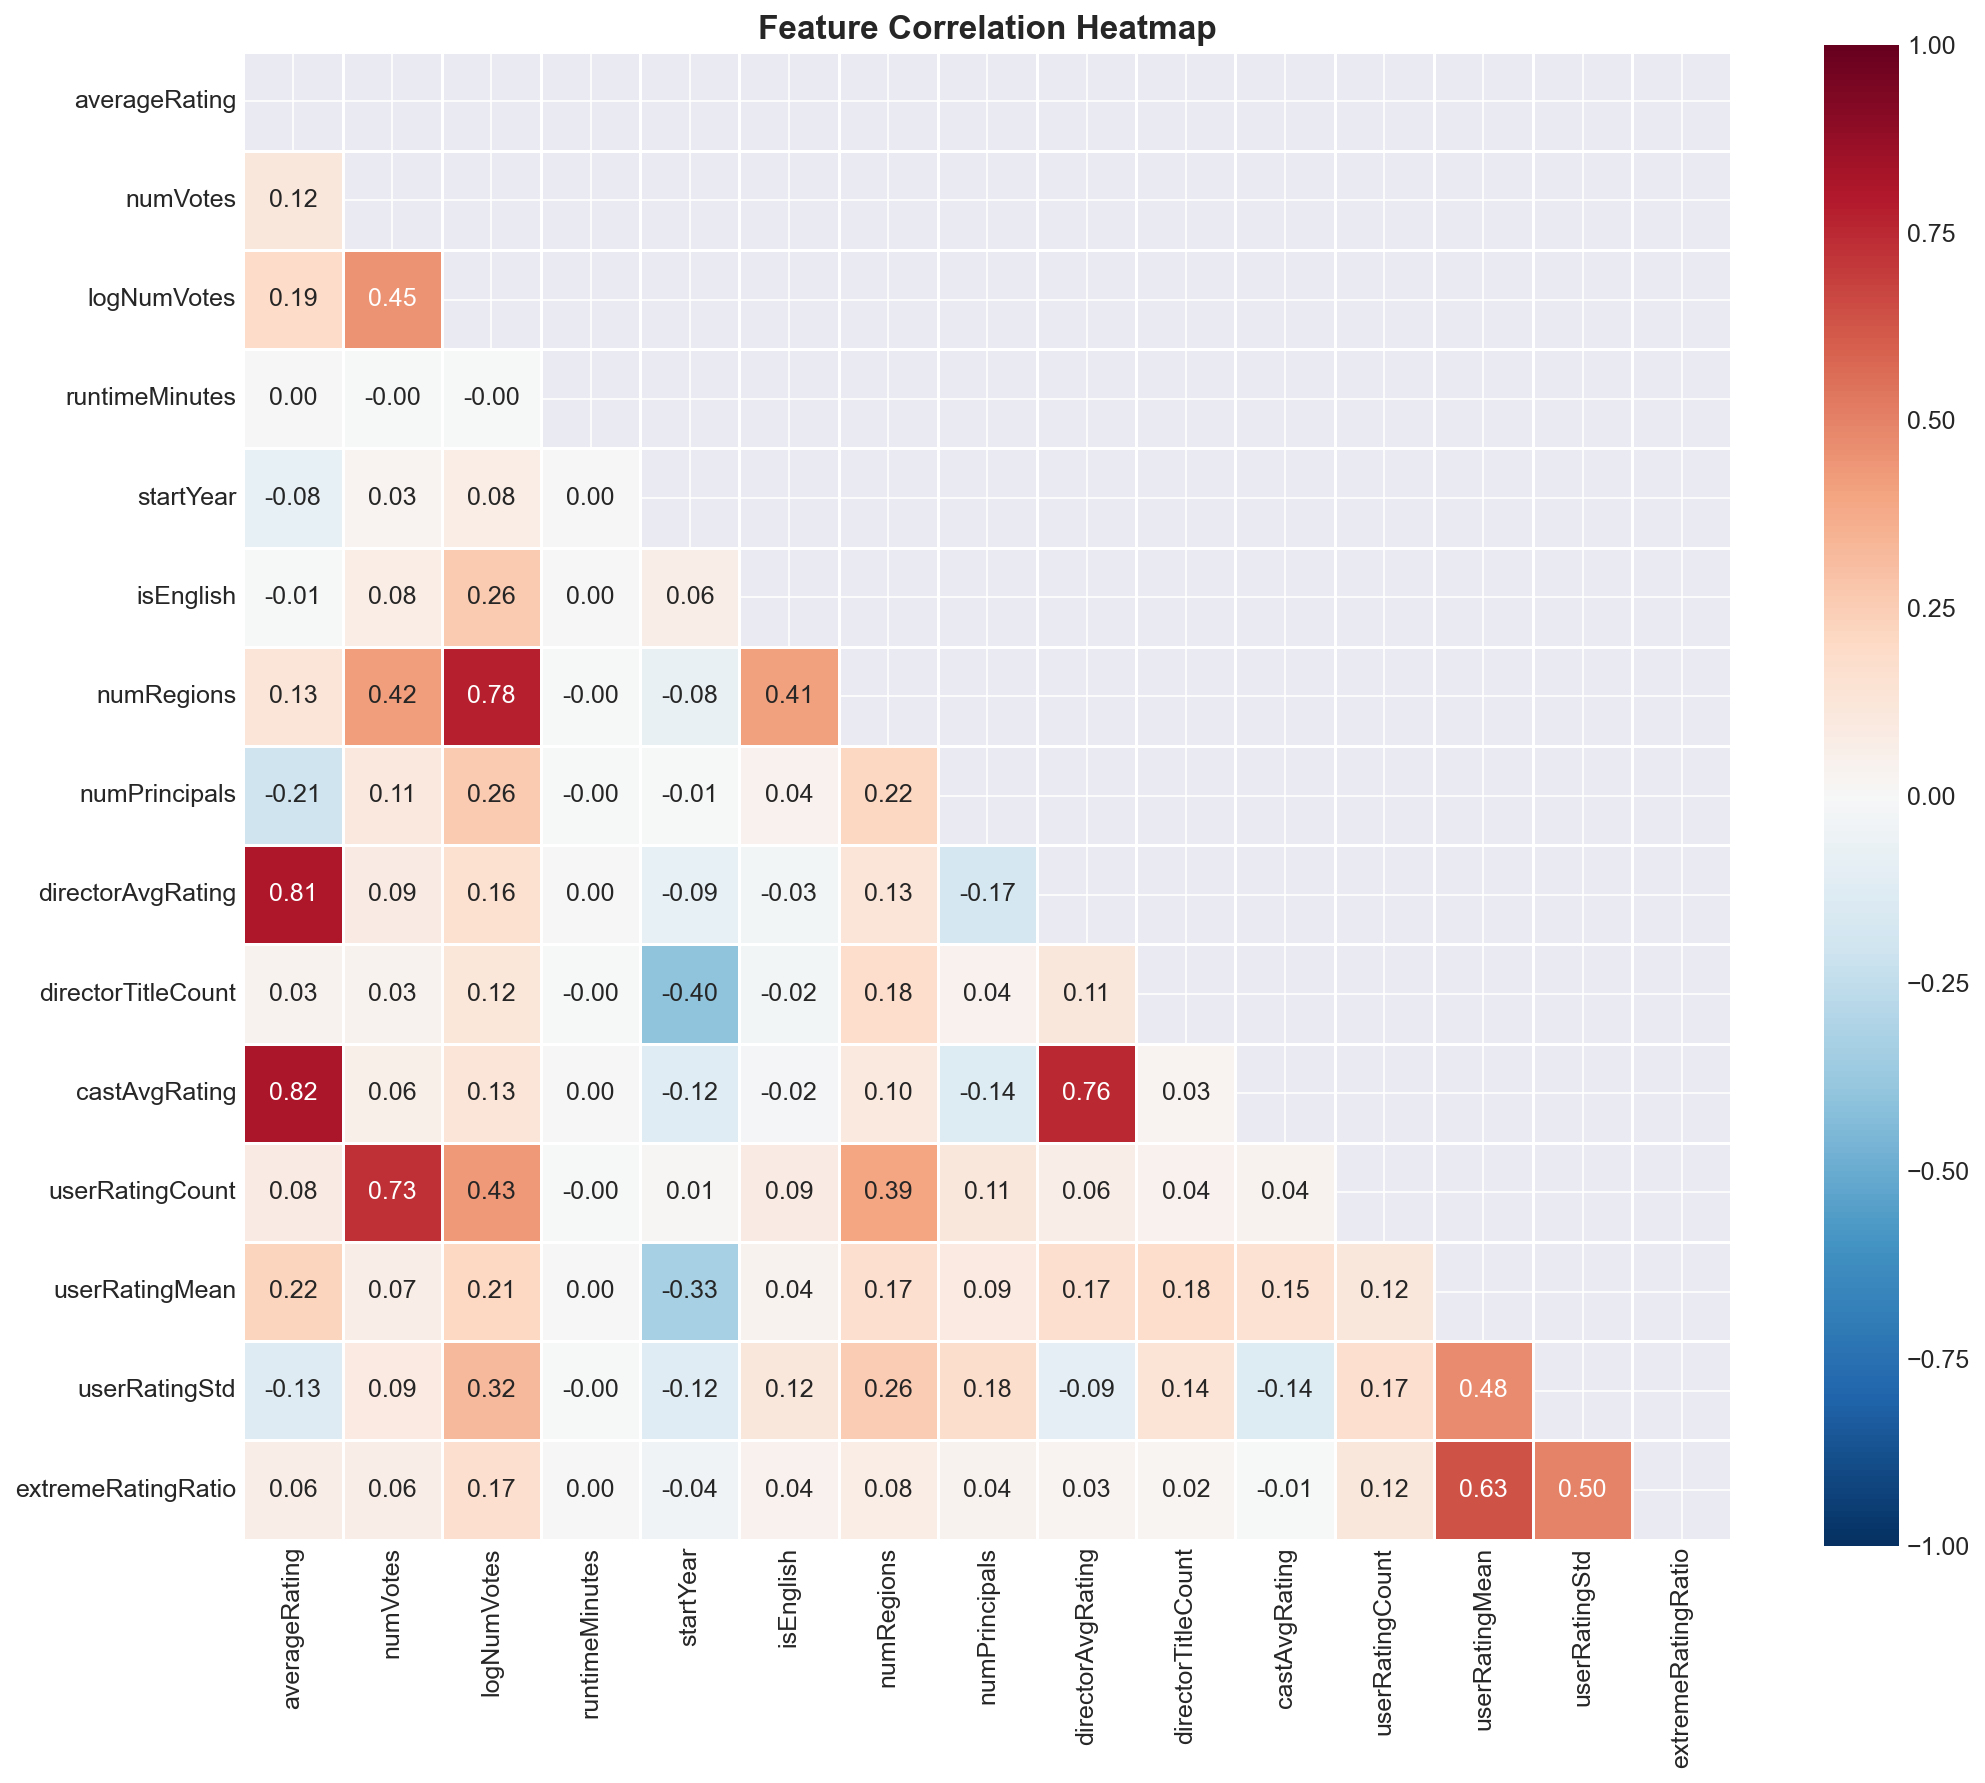

In [10]:

corr_cols = [
    'averageRating', 'numVotes', 'logNumVotes', 'runtimeMinutes',
    'startYear', 'isEnglish', 'numRegions', 'numPrincipals',
    'directorAvgRating', 'directorTitleCount', 'castAvgRating',
    'userRatingCount', 'userRatingMean', 'userRatingStd', 'extremeRatingRatio'
]
# Collect only the 15 correlation columns (not the 50+ column full dataset)
corr_pdf = df_spark.select(corr_cols).toPandas()
corr_matrix = corr_pdf.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.savefig(os.path.join(PLOTS_DIR, '07_correlation_heatmap.png'), bbox_inches='tight')
plt.show()


## Plot 8: Director & Cast Quality vs. Title Rating

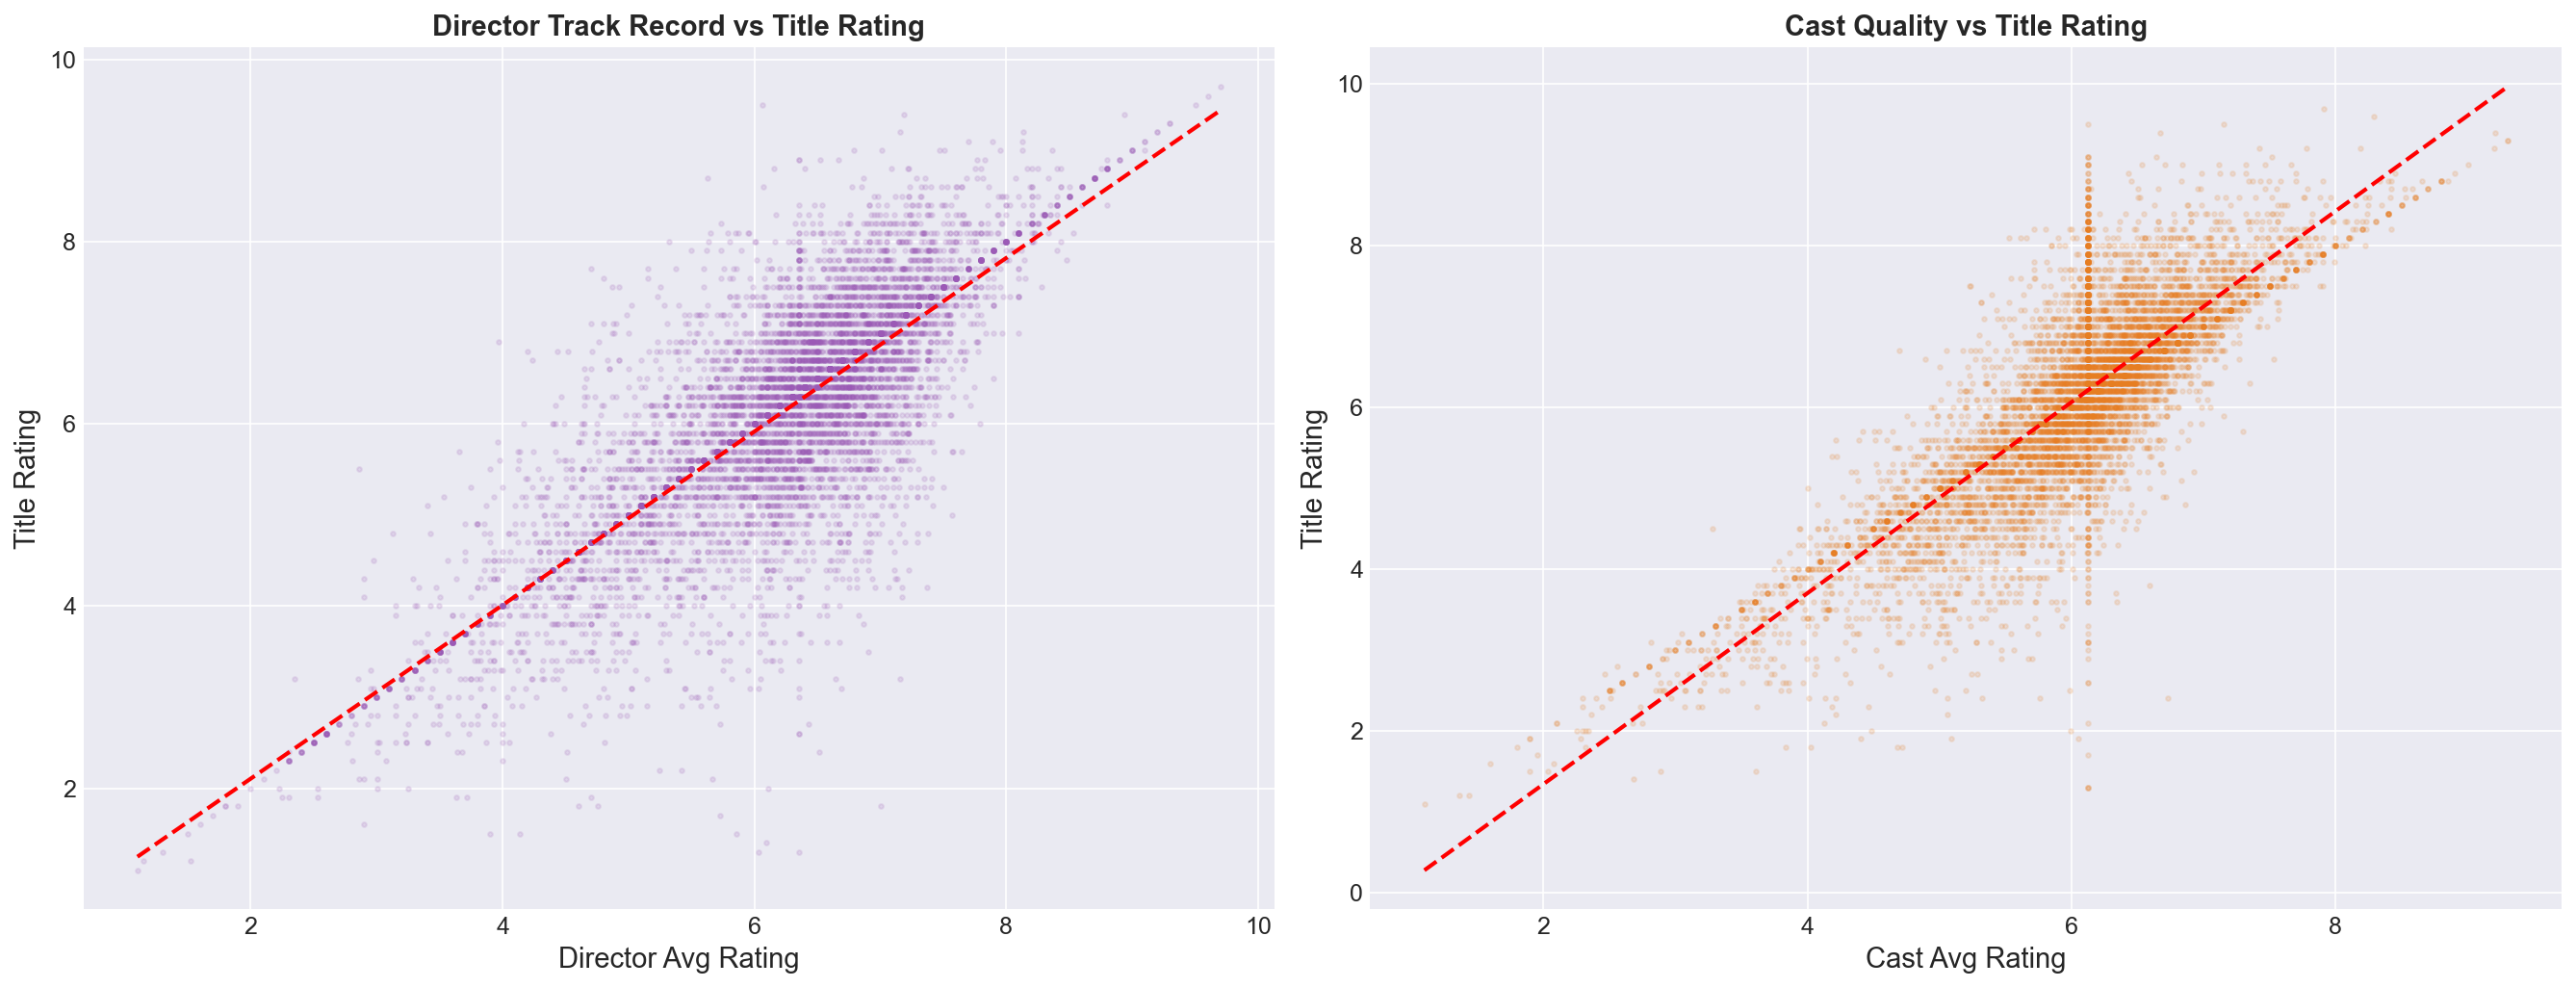

In [11]:

# Sample only the 3 needed columns in Spark
sample = (
    df_spark
    .select("directorAvgRating", "castAvgRating", "averageRating")
    .sample(fraction=0.1, seed=42)
    .limit(8000)
    .toPandas()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.scatter(sample['directorAvgRating'], sample['averageRating'],
            alpha=0.15, s=5, c='#9b59b6')
z1 = np.polyfit(sample['directorAvgRating'].dropna(),
                sample.loc[sample['directorAvgRating'].notna(), 'averageRating'], 1)
p1 = np.poly1d(z1)
x_line = np.linspace(sample['directorAvgRating'].min(), sample['directorAvgRating'].max(), 100)
ax1.plot(x_line, p1(x_line), 'r--', linewidth=2)
ax1.set_xlabel('Director Avg Rating', fontsize=14)
ax1.set_ylabel('Title Rating', fontsize=14)
ax1.set_title('Director Track Record vs Title Rating', fontsize=14, fontweight='bold')

ax2.scatter(sample['castAvgRating'], sample['averageRating'],
            alpha=0.15, s=5, c='#e67e22')
z2 = np.polyfit(sample['castAvgRating'].dropna(),
                sample.loc[sample['castAvgRating'].notna(), 'averageRating'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(sample['castAvgRating'].min(), sample['castAvgRating'].max(), 100)
ax2.plot(x_line2, p2(x_line2), 'r--', linewidth=2)
ax2.set_xlabel('Cast Avg Rating', fontsize=14)
ax2.set_ylabel('Title Rating', fontsize=14)
ax2.set_title('Cast Quality vs Title Rating', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '08_director_cast_quality.png'), bbox_inches='tight')
plt.show()


## Plot 9: Rating Tier Distribution

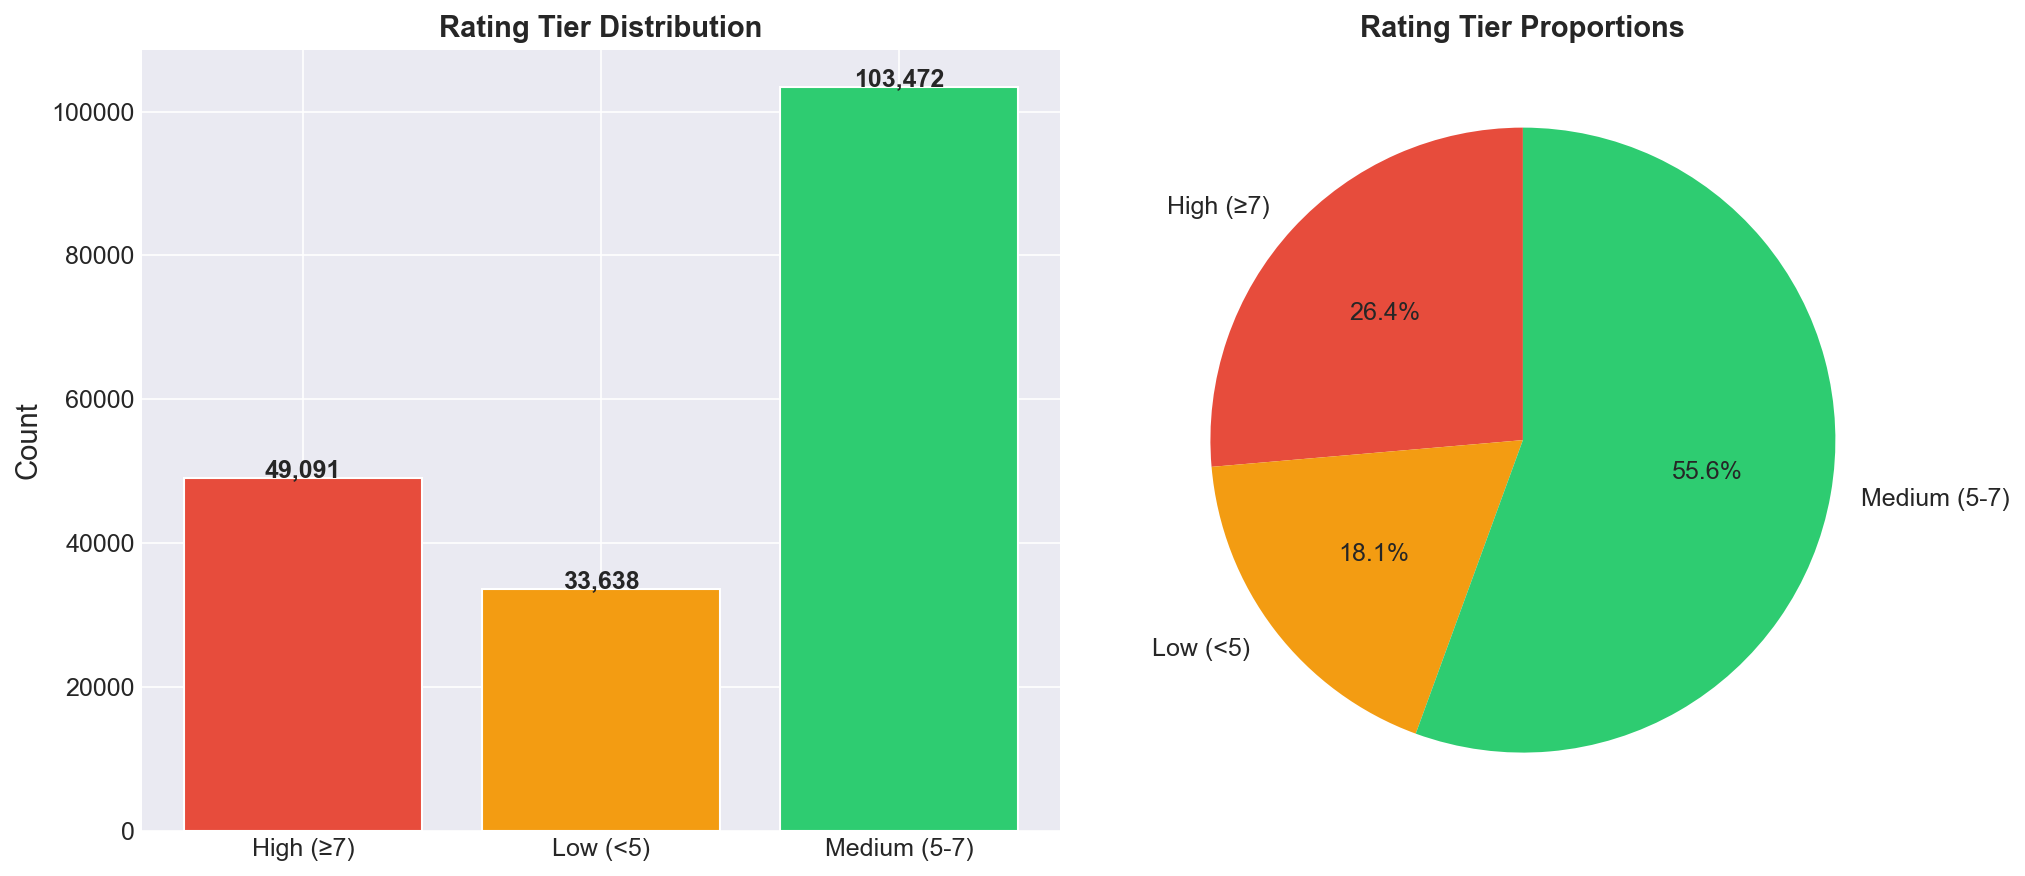

In [12]:

# Collect only the 3-row grouped result from Spark
tier_counts = (
    df_spark
    .groupBy("ratingTierLabel")
    .count()
    .orderBy("ratingTierLabel")
    .toPandas()
    .set_index("ratingTierLabel")["count"]
)
colors = ['#e74c3c', '#f39c12', '#2ecc71']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(tier_counts.index, tier_counts.values, color=colors, edgecolor='white')
ax1.set_ylabel('Count', fontsize=14)
ax1.set_title('Rating Tier Distribution', fontsize=14, fontweight='bold')
for i, (idx, val) in enumerate(tier_counts.items()):
    ax1.text(i, val + 100, f'{val:,}', ha='center', fontweight='bold')

ax2.pie(tier_counts.values, labels=tier_counts.index, colors=colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax2.set_title('Rating Tier Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '09_rating_tiers.png'), bbox_inches='tight')
plt.show()


## Plot 10: User Rating Agreement

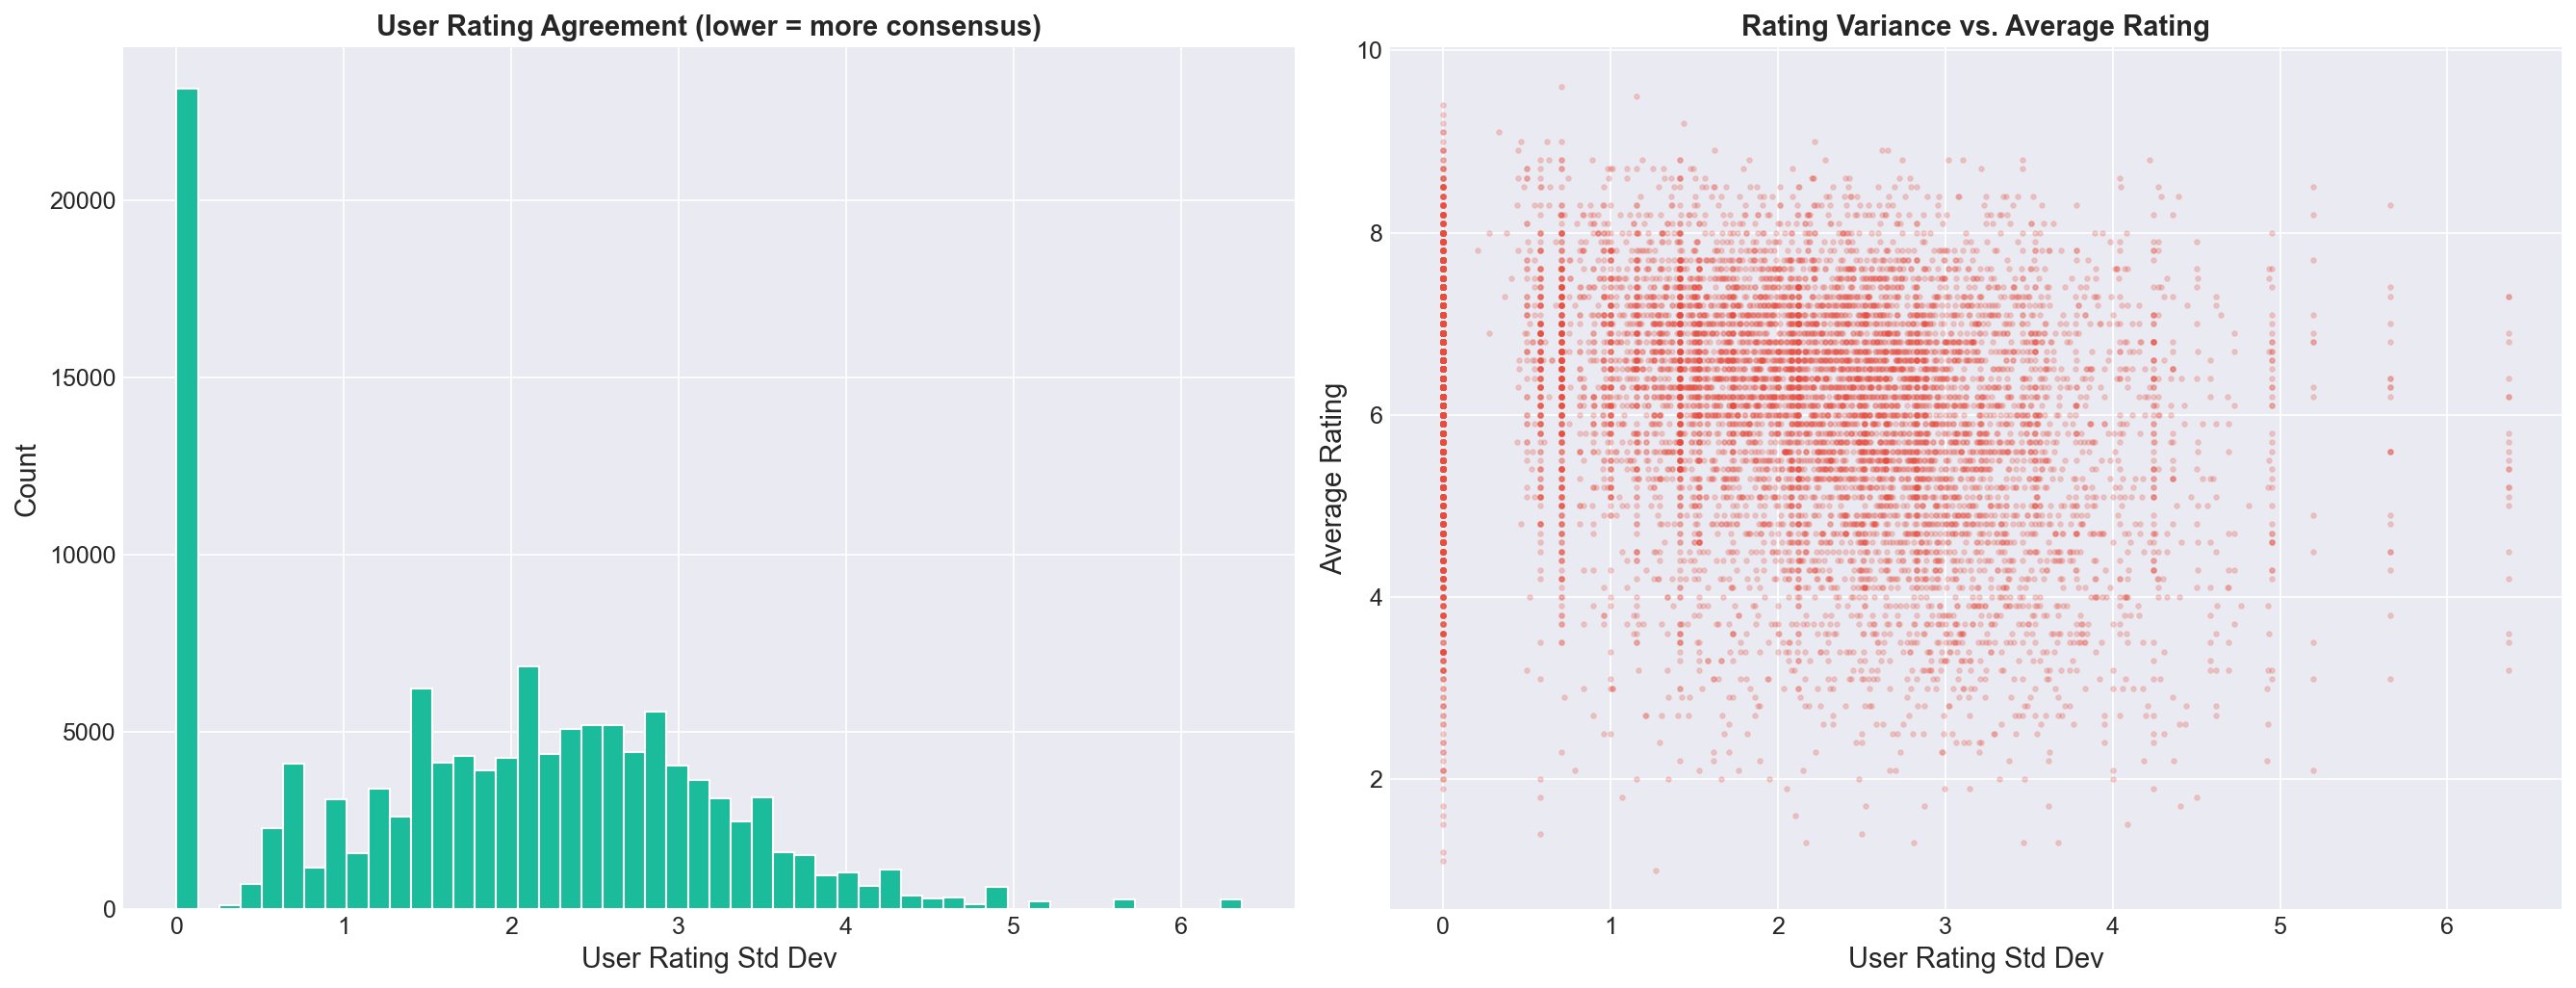


Titles with user ratings: 127,803
Mean user rating std: 1.88

Done! Proceed to 04_modeling.ipynb


In [13]:

df_user_spark = df_spark.filter(F.col("userRatingCount") > 0)

# Collect summary stats in Spark (no data to driver)
user_stats = df_user_spark.agg(
    F.count("*").alias("n"),
    F.round(F.mean("userRatingStd"), 2).alias("mean_std")
).first()

# Collect only the 2 needed columns for histogram and scatter
user_pdf = df_user_spark.select("userRatingStd", "averageRating").toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.hist(user_pdf['userRatingStd'], bins=50, color='#1abc9c', edgecolor='white')
ax1.set_xlabel('User Rating Std Dev', fontsize=14)
ax1.set_ylabel('Count', fontsize=14)
ax1.set_title('User Rating Agreement (lower = more consensus)', fontsize=14, fontweight='bold')

scatter_sample = user_pdf.sample(min(10000, len(user_pdf)), random_state=42)
ax2.scatter(scatter_sample['userRatingStd'], scatter_sample['averageRating'],
            alpha=0.2, s=5, c='#e74c3c')
ax2.set_xlabel('User Rating Std Dev', fontsize=14)
ax2.set_ylabel('Average Rating', fontsize=14)
ax2.set_title('Rating Variance vs. Average Rating', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '10_user_agreement.png'), bbox_inches='tight')
plt.show()

print(f"\nTitles with user ratings: {user_stats['n']:,}")
print(f"Mean user rating std: {user_stats['mean_std']:.2f}")
print("\nDone! Proceed to 04_modeling.ipynb")
